In [1]:
import sionna.rt as rt
import mitsuba as mi
import numpy as np
from numpy.lib.stride_tricks import sliding_window_view
import drjit as dr
import matplotlib.pyplot as plt


In [2]:
# create a random rectangle
num_rows = 30
num_cols = 40
radius = 10
x, y = np.meshgrid(
    np.linspace(-radius, radius, num_cols), 
    np.linspace(-radius, radius, num_rows))
elevation = 0.1 * mi.TensorXf(np.cos(np.sqrt(x**2 + y**2)))

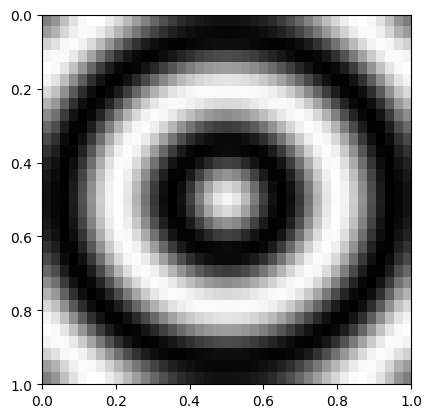

In [ ]:
plt.imshow(elevation.numpy(), cmap="gray", extent=(0, 1, 1, 0))
plt.show()

In [5]:
mesh = rt.utils.geometry.triangulate_elevation(elevation)

AttributeError: 'numpy.ndarray' object has no attribute 'numpy'

In [ ]:
def default_array(num_rows: int = 1, num_cols: int = 1,
                  vertical_spacing: float = 0.5, horizontal_spacing: float = 0.5,
                  pattern: str = "iso", polarization: str = "V"):
    return rt.PlanarArray(num_rows=num_rows,
                       num_cols=num_cols,
                       vertical_spacing=vertical_spacing,
                       horizontal_spacing=horizontal_spacing,
                       pattern=pattern,
                       polarization=polarization)

In [ ]:
# from Anshul's notebook
mat_lunar_highland = rt.RadioMaterial(
    name="lunar-highland",
    thickness=11,
    relative_permittivity=2.7,
    conductivity=10**(-12.5),
    scattering_coefficient=0.4,
    xpd_coefficient=0.1,
    scattering_pattern='lambertian',
    frequency_update_callback=None,
    color=None,
    props=None)

props = mi.Properties()
props["material"] = mat_lunar_highland
props["material"] = rt.ITURadioMaterial("mat", itu_type="concrete", thickness=10)
# props["material"] = rt.RadioMaterial("mat", thickness=10, relative_permittivity=100)
# Sionna requires bsdfs to be wrapped in HolderMaterial
props["material"] = rt.HolderMaterial(props)
mi_mesh = mi.Mesh(name="terrain",
                  vertex_count=mesh.vertex_count(),
                  face_count=mesh.face_count(), 
                  props=props)
mesh_params = mi.traverse(mesh)
mi_mesh_params = mi.traverse(mi_mesh)
mi_mesh_params["vertex_positions"] = 10 * mesh_params["vertex_positions"]
mi_mesh_params["faces"] = mesh_params["faces"]
mi_mesh_params.update()
mi_scene = mi.load_dict({
    "type": "scene",
    "terrain": mi_mesh
})
scene = rt.Scene(mi_scene)
scene.tx_array = default_array()
scene.rx_array = default_array(polarization="VH")

tx = rt.Transmitter(name="tx",
                    # position=10 * mi.Point3f(0.07, 0.25, 0.15),
                    position=10 * mi.Point3f(0.07, 0.25, 0.1),
                    orientation=mi.Point3f(0, 0, 0),
                    power_dbm=100)
scene.add(tx)

In [ ]:
rm_solver = rt.RadioMapSolver()
rm = rm_solver(
    scene=scene,
    cell_size=[10, 10],
    # evaluate 10cm above the surface
    digital_elevation_model=elevation + 1,
    samples_per_tx=int(1e8),
    max_depth=0,
    los=True,
    specular_reflection=True,
    diffuse_reflection=False,
    refraction=False
)

In [ ]:
fig, axs = plt.subplots(ncols=2, layout="constrained")
axs[0].imshow(rm.path_gain.numpy().squeeze(), norm="log")
axs[1].imshow(rm.path_gain.numpy().squeeze())
# axs[1].imshow(elevation.numpy(), cmap="grey")

In [ ]:
cam = rt.Camera(position=[-15, 10, 5], look_at=[5, 5, 2])
scene.render(camera=cam, show_devices=True);
# scene.preview(show_devices=True);